# Bootstrap, bagging and random forests

Single decision trees are interpretable but unstable: a slightly different sample can produce a very different tree. Ensembles fix this by **averaging many trees**, each grown on a different bootstrap sample of the data.

This notebook builds up the idea in three steps:

1. **The bootstrap**: resampling the data to measure the uncertainty of any estimator, validated against a simulation where the true answer is known.
2. **Bagging and random forests**: averaging bootstrapped trees, the out-of-bag error, and why random forests decorrelate the trees.
3. **A real diagnostic problem**: classifying breast tumours as benign or malignant, comparing a single tree, bagging, a random forest and logistic regression, and interpreting the forest with feature importances.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.dpi"] = 100

## 1. The bootstrap

A bootstrap sample draws $n$ observations **with replacement** from a dataset of size $n$. Some observations appear several times, others not at all. The probability that a given observation is never drawn is

$$\left(1 - \frac{1}{n}\right)^n \xrightarrow{n \to \infty} e^{-1} \approx 0.368 .$$

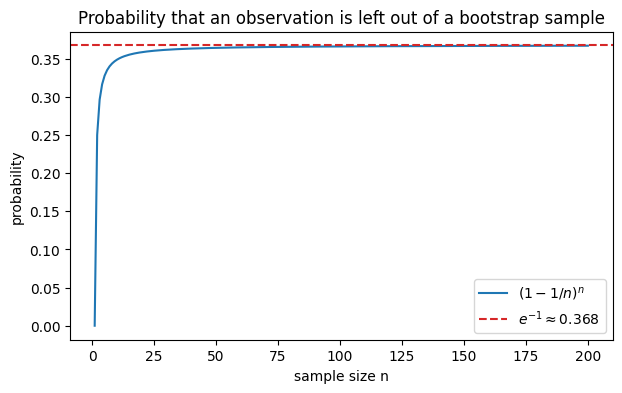

Simulated share of observations left out (n = 1000): 0.368


In [2]:
n = np.arange(1, 201)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n, (1 - 1 / n) ** n, label=r"$(1 - 1/n)^n$")
ax.axhline(np.exp(-1), color="tab:red", ls="--", label=r"$e^{-1} \approx 0.368$")
ax.set(xlabel="sample size n", ylabel="probability", title="Probability that an observation is left out of a bootstrap sample")
ax.legend()
plt.show()

rng = np.random.default_rng(0)
left_out = np.mean([len(np.setdiff1d(np.arange(1000), rng.integers(0, 1000, 1000))) / 1000 for _ in range(500)])
print(f"Simulated share of observations left out (n = 1000): {left_out:.3f}")

So each bootstrap sample contains about **63%** of the distinct observations, and the remaining **37% are "out of bag"**. We will use these left-out observations later as a free validation set.

### Measuring uncertainty without a formula

Suppose we split an investment between two assets with returns $X$ and $Y$, putting a fraction $\alpha$ in $X$. The variance of the portfolio is minimized by

$$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}} .$$

We can estimate $\alpha$ by plugging in sample variances and covariance, but there is no simple formula for the standard error of $\hat\alpha$. The bootstrap gives one: resample the data many times, recompute $\hat\alpha$ on each resample, and take the standard deviation of the results.

We simulate 250 joint returns from a known distribution, so we can check the bootstrap against the truth.

In [3]:
mean, cov = [12, 53], [[5, -12], [-12, 53]]
true_alpha = (cov[1][1] - cov[0][1]) / (cov[0][0] + cov[1][1] - 2 * cov[0][1])

def estimate_alpha(data):
    c = np.cov(data, rowvar=False)
    return (c[1, 1] - c[0, 1]) / (c[0, 0] + c[1, 1] - 2 * c[0, 1])

rng = np.random.default_rng(0)
returns = rng.multivariate_normal(mean, cov, size=250)
print(f"true alpha = {true_alpha:.4f}, estimate from the sample = {estimate_alpha(returns):.4f}")

boot = np.array([estimate_alpha(returns[rng.integers(0, 250, 250)]) for _ in range(2000)])
truth = np.array([estimate_alpha(rng.multivariate_normal(mean, cov, size=250)) for _ in range(2000)])
print(f"bootstrap standard error (one sample, 2000 resamples): {boot.std(ddof=1):.5f}")
print(f"true standard error (2000 fresh samples):             {truth.std(ddof=1):.5f}")

true alpha = 0.7927, estimate from the sample = 0.7941


bootstrap standard error (one sample, 2000 resamples): 0.00844
true standard error (2000 fresh samples):             0.00846


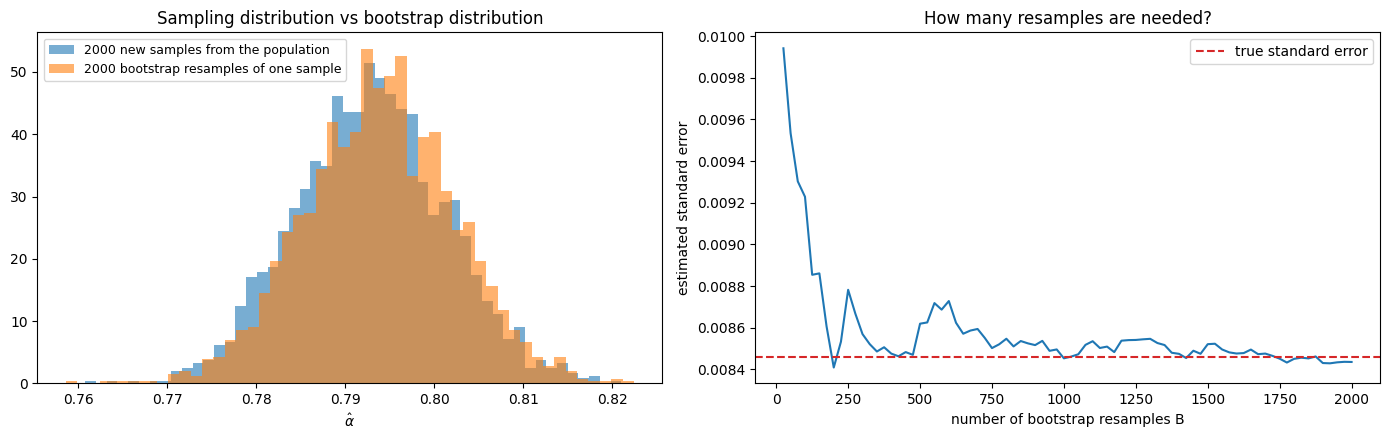

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.hist(truth, bins=50, alpha=0.6, density=True, label="2000 new samples from the population")
ax1.hist(boot, bins=50, alpha=0.6, density=True, label="2000 bootstrap resamples of one sample")
ax1.set(xlabel=r"$\hat\alpha$", title="Sampling distribution vs bootstrap distribution")
ax1.legend(fontsize=9)

sizes = np.arange(25, 2001, 25)
running = [boot[:b].std(ddof=1) for b in sizes]
ax2.plot(sizes, running)
ax2.axhline(truth.std(ddof=1), color="tab:red", ls="--", label="true standard error")
ax2.set(xlabel="number of bootstrap resamples B", ylabel="estimated standard error", title="How many resamples are needed?")
ax2.legend()
fig.tight_layout()
plt.show()

From a **single** dataset, the bootstrap recovers the standard error almost exactly. The bootstrap distribution has the same spread as the true sampling distribution, although it is centred on the sample estimate rather than on the true value. The estimate settles after roughly 500–1,000 resamples.

In real problems we never have the population, only one sample, which is what makes the bootstrap so useful.

## 2. Bagging and random forests: breast tumour diagnosis

The dataset contains 569 breast masses examined with a fine needle aspirate. For each one, ten characteristics of the cell nuclei are measured from a digitized image (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension), each summarized by its mean, standard error and worst (largest) value: 30 features in total. The diagnosis is benign (B) or malignant (M).

In [5]:
cancer = pd.read_csv("data/breast_cancer.csv")
X = cancer.drop(columns=["id", "diagnosis"])
y = (cancer["diagnosis"] == "M").astype(int)
print(f"{len(cancer)} masses, {y.mean():.1%} malignant, {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

569 masses, 37.3% malignant, 30 features


**Bagging** (bootstrap aggregating) grows a deep tree on each of $B$ bootstrap samples and lets them vote. Each tree overfits, but in different ways, and averaging cancels much of the noise.

The trees of a bagged ensemble are still similar to each other: if one feature is very strong, every tree splits on it first. A **random forest** adds a twist: at each split only a random subset of $m$ features is considered (typically $m = \sqrt{p}$). This forces the trees to differ, and averaging less correlated trees reduces the variance further. Bagging is the special case $m = p$.

Because each tree never sees about 37% of the training data, every observation can be predicted by the trees that did not use it. The resulting **out-of-bag (OOB) error** is a validation error that comes for free, without a separate validation set.

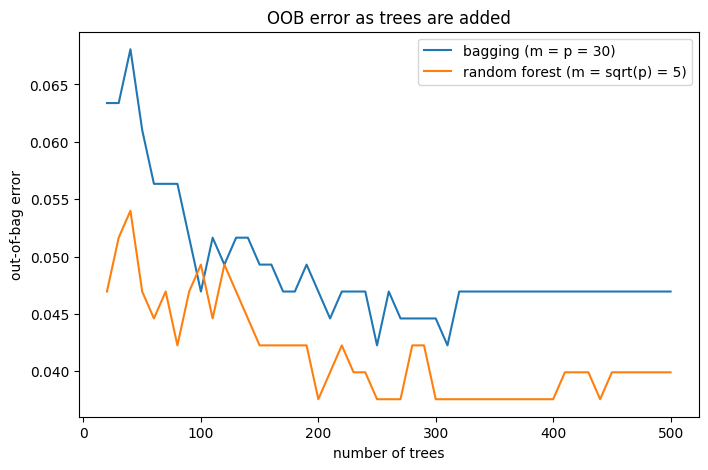

In [6]:
sizes = np.arange(20, 501, 10)
oob = {"bagging (m = p = 30)": [], "random forest (m = sqrt(p) = 5)": []}
for name, max_features in [("bagging (m = p = 30)", None), ("random forest (m = sqrt(p) = 5)", "sqrt")]:
    forest = RandomForestClassifier(max_features=max_features, oob_score=True, warm_start=True, random_state=1)
    for b in sizes:
        forest.set_params(n_estimators=b).fit(X_train, y_train)
        oob[name].append(1 - forest.oob_score_)

fig, ax = plt.subplots(figsize=(8, 5))
for name, errors in oob.items():
    ax.plot(sizes, errors, label=name)
ax.set(xlabel="number of trees", ylabel="out-of-bag error", title="OOB error as trees are added")
ax.legend()
plt.show()

The OOB error drops quickly and stabilizes after a few hundred trees. Adding more trees never causes overfitting; it only costs computing time, so 500 trees is a safe choice here. The random forest settles at a lower error than bagging, as expected from decorrelating the trees.

### Comparing models

We compare four models with 10-fold cross-validation on the training set and then on the held-out test set:

In [7]:
models = {
    "single tree": DecisionTreeClassifier(random_state=0),
    "bagging": RandomForestClassifier(n_estimators=500, max_features=None, random_state=0),
    "random forest": RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=0),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
rows = {}
for name, model in models.items():
    cv_error = 1 - cross_val_score(model, X_train, y_train, cv=cv).mean()
    model.fit(X_train, y_train)
    rows[name] = {
        "CV error": cv_error,
        "test error": 1 - model.score(X_test, y_test),
        "test recall (malignant found)": recall_score(y_test, model.predict(X_test)),
    }
pd.DataFrame(rows).T.round(3)

,CV error,test error,test recall (malignant found)
single tree,0.073,0.063,0.887
bagging,0.045,0.035,0.906
random forest,0.042,0.028,0.925
logistic regression,0.028,0.035,0.925


Averaging trees pays off: bagging and the random forest roughly halve the error of a single tree, and the random forest is the best of the tree-based models. On this dataset, however, plain **logistic regression is just as good** (it even has the lowest cross-validated error). The classes are separated well by a smooth combination of the size and shape features, which is exactly what a linear model captures. A random forest is a strong default, but it is not automatically better than a simpler model, and the comparison is worth making.

With a test set of 143 masses, a difference of one or two misclassified cases changes the error by about one percentage point, so the differences between the three good models are within noise.

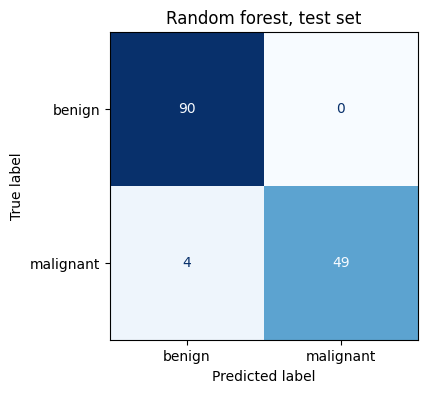

In [8]:
forest = models["random forest"]
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Random forest, test set")
plt.show()

In a diagnostic setting the two errors are not equivalent: a malignant tumour classified as benign (a false negative) is far more serious than a false alarm, which leads to further tests. As in the logistic regression notebook, the decision threshold could be lowered to catch more malignant cases at the price of more false alarms.

### What does the forest look at?

A forest of 500 trees cannot be read like a single tree, but we can measure how much it relies on each feature. Two common measures can tell different stories:

- **impurity-based importance**: the total decrease in Gini impurity produced by splits on each feature, computed on the training data;
- **permutation importance**: the drop in test accuracy when the values of a feature are randomly shuffled.

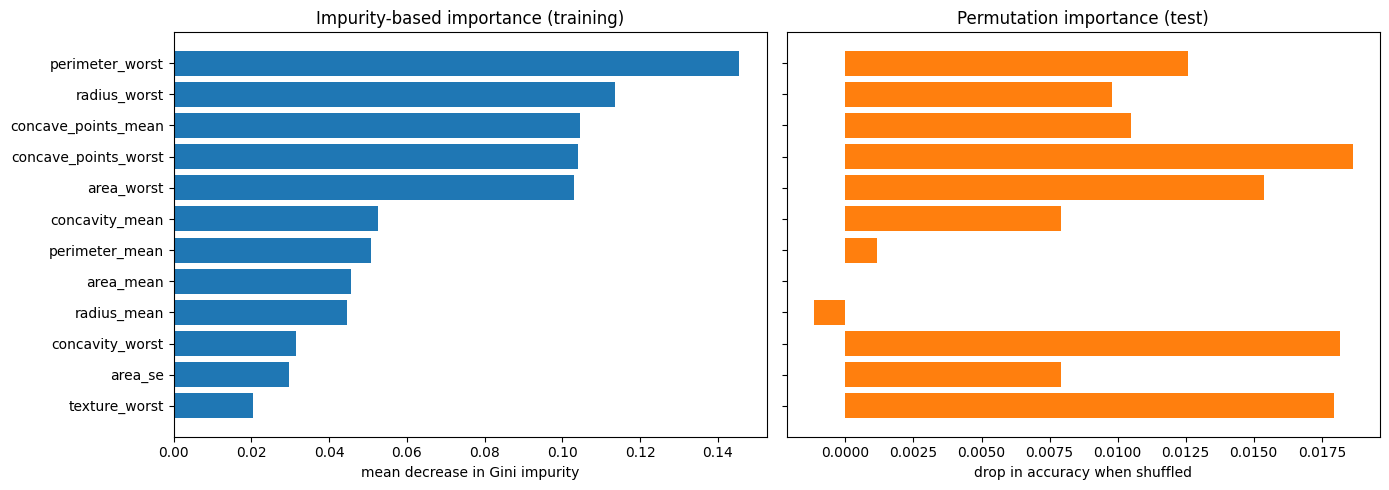

In [9]:
impurity = pd.Series(forest.feature_importances_, index=X.columns)
perm = permutation_importance(forest, X_test, y_test, n_repeats=30, random_state=0)
permutation = pd.Series(perm.importances_mean, index=X.columns)

top = impurity.sort_values(ascending=False).head(12).index
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax1.barh(top[::-1], impurity[top[::-1]], color="tab:blue")
ax1.set(title="Impurity-based importance (training)", xlabel="mean decrease in Gini impurity")
ax2.barh(top[::-1], permutation[top[::-1]], color="tab:orange")
ax2.set(title="Permutation importance (test)", xlabel="drop in accuracy when shuffled")
fig.tight_layout()
plt.show()

In [10]:
size_features = ["radius_worst", "perimeter_worst", "area_worst", "radius_mean", "perimeter_mean", "area_mean"]
X[size_features].corr().round(2)

,radius_worst,perimeter_worst,area_worst,radius_mean,perimeter_mean,area_mean
radius_worst,1.00,0.99,0.98,0.97,0.97,0.96
perimeter_worst,0.99,1.00,0.98,0.97,0.97,0.96
area_worst,0.98,0.98,1.00,0.94,0.94,0.96
radius_mean,0.97,0.97,0.94,1.00,1.00,0.99
perimeter_mean,0.97,0.97,0.94,1.00,1.00,0.99
area_mean,0.96,0.96,0.96,0.99,0.99,1.00


The two measures agree on the general picture: the **"worst" values** of the size features (perimeter, radius, area) and the **concave points** of the nuclei carry most of the signal. Malignant nuclei are larger and more irregular. They disagree on the details: permutation importance ranks `concavity_worst` and `texture_worst` among the most useful features, while the impurity measure places them near the bottom, and it gives no credit at all to the mean size features.

The reason is correlation. Radius, perimeter and area are almost perfectly correlated (r between 0.94 and 0.99, for both the mean and the worst values). When one of them is shuffled, the forest still has the others, so accuracy barely drops; features without a close substitute, like texture, look more important by comparison. The impurity-based measure instead **splits the credit** among correlated features in a way that depends on which one each tree happened to pick. Neither measure answers "what would happen without this information": with groups of correlated features, importance should be read at the level of the group.

Plotting the two most important features shows how well the classes separate:

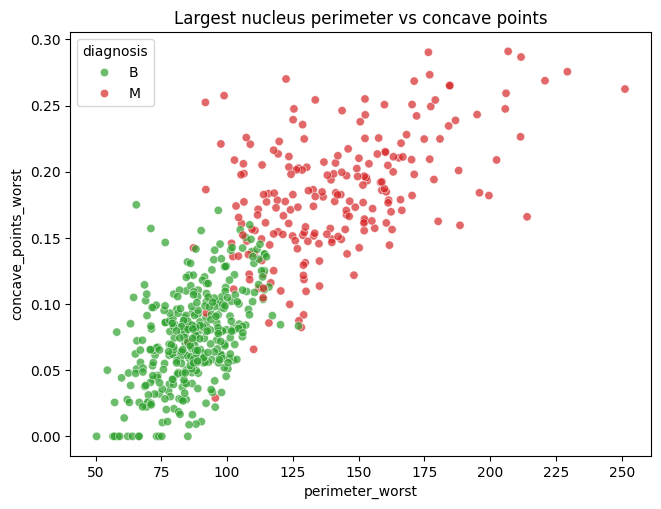

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=cancer, x="perimeter_worst", y="concave_points_worst", hue="diagnosis",
                hue_order=["B", "M"], palette=["tab:green", "tab:red"], alpha=0.7, ax=ax)
ax.set(title="Largest nucleus perimeter vs concave points")
plt.show()

Two features alone already separate most of the benign (small, regular nuclei) and malignant (large, irregular nuclei) masses, with an overlap zone where the other features and the averaging of many trees make the difference.

## Summary

- The **bootstrap** estimates the uncertainty of any statistic from a single sample, and here it matched the true standard error almost exactly.
- **Bagging** averages trees grown on bootstrap samples; **random forests** also decorrelate them by sampling features at each split. Both strongly reduce the variance of a single tree.
- The **out-of-bag error** is a free validation estimate; more trees never overfit.
- Ensembles are a strong default, but a **simpler model can be just as accurate**; always compare.
- **Feature importances** must be interpreted with care when features are correlated: impurity-based scores split the credit, while permutation scores underestimate each member of a correlated group.